In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Loading

In [59]:
orders=pd.read_csv('olist_orders_dataset.csv')
order_items=pd.read_csv('olist_order_items_dataset.csv')
customers=pd.read_csv('olist_customers_dataset.csv')
products=pd.read_csv('olist_products_dataset.csv')

In [60]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [61]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [62]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [63]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Understanding of Data

In [64]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [65]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [66]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [67]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [68]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [69]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [70]:
orders = orders[['order_id','customer_id','order_purchase_timestamp']]
order_items = order_items[['order_id','product_id','price']]
customers = customers[['customer_id','customer_city']]
products = products[['product_id','product_category_name']]

### Merge the dataset which're important for further analysis

In [71]:
df = orders.merge(customers, on='customer_id', how='left')

In [72]:
df = df.merge(order_items, on='order_id', how='left')

In [73]:
df = df.merge(products, on='product_id', how='left')

In [74]:
df.head()

,order_id,customer_id,order_purchase_timestamp,customer_city,product_id,price,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,sao paulo,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,barreiras,595fac2a385ac33a80bd5114aec74eb8,118.70,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,vianopolis,aa4383b373c6aca5d8797843e5594415,159.90,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,sao goncalo do amarante,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,santo andre,65266b2da20d04dbe00c5c2d3bb7859e,19.90,papelaria


### Feature Engineering

In [75]:
df['order_date'] = df['order_purchase_timestamp'].dt.date

In [76]:
df['revenue'] = df['price']

In [77]:
df['month'] = df['order_purchase_timestamp'].dt.month
df['year'] = df['order_purchase_timestamp'].dt.year

In [78]:
df

,order_id,customer_id,order_purchase_timestamp,customer_city,product_id,price,product_category_name,order_date,revenue,month,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,sao paulo,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,2017-10-02,29.99,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,barreiras,595fac2a385ac33a80bd5114aec74eb8,118.70,perfumaria,2018-07-24,118.70,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,vianopolis,aa4383b373c6aca5d8797843e5594415,159.90,automotivo,2018-08-08,159.90,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,sao goncalo do amarante,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,pet_shop,2017-11-18,45.00,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,santo andre,65266b2da20d04dbe00c5c2d3bb7859e,19.90,papelaria,2018-02-13,19.90,2,2018
...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,praia grande,f1d4ce8c6dd66c47bbaa8c6781c2a923,174.90,bebes,2018-02-06,174.90,2,2018
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,nova vicosa,b80910977a37536adeddd63663f916ad,205.99,eletrodomesticos_2,2017-08-27,205.99,8,2017
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,japuiba,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,informatica_acessorios,2018-01-08,179.99,1,2018
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,japuiba,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,informatica_acessorios,2018-01-08,179.99,1,2018


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  113425 non-null  object        
 1   customer_id               113425 non-null  object        
 2   order_purchase_timestamp  113425 non-null  datetime64[ns]
 3   customer_city             113425 non-null  object        
 4   product_id                112650 non-null  object        
 5   price                     112650 non-null  float64       
 6   product_category_name     111047 non-null  object        
 7   order_date                113425 non-null  object        
 8   revenue                   112650 non-null  float64       
 9   month                     113425 non-null  int32         
 10  year                      113425 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(2), object(6)
memory usag

In [80]:
df.isnull().sum()

order_id                       0
customer_id                    0
order_purchase_timestamp       0
customer_city                  0
product_id                   775
price                        775
product_category_name       2378
order_date                     0
revenue                      775
month                          0
year                           0
dtype: int64

In [81]:
print(len(df))

113425


In [82]:
df = df.dropna(subset=['product_id', 'price', 'product_category_name'])

In [83]:
print(len(df))

111047


In [84]:
df.to_csv("cleaned_data.csv", index=False)

### Data Insights:

In [85]:
print("Total Revenue:", round(df['revenue'].sum(),2))

Total Revenue: 13412108.42


In [86]:
print(f"Total Revenue: {df['revenue'].sum():,.2f}")

Total Revenue: 13,412,108.42


In [87]:
print(df.groupby('customer_city')['revenue'].sum().head())

customer_city
abadia dos dourados     358.90
abadiania               949.99
abaete                 1695.91
abaetetuba             4028.57
abaiara                 262.90
Name: revenue, dtype: float64


In [88]:
print(df.groupby('product_category_name')['revenue'].sum().head())

product_category_name
agro_industria_e_comercio    72530.47
alimentos                    29393.41
alimentos_bebidas            15179.48
artes                        24202.64
artes_e_artesanato            1814.01
Name: revenue, dtype: float64


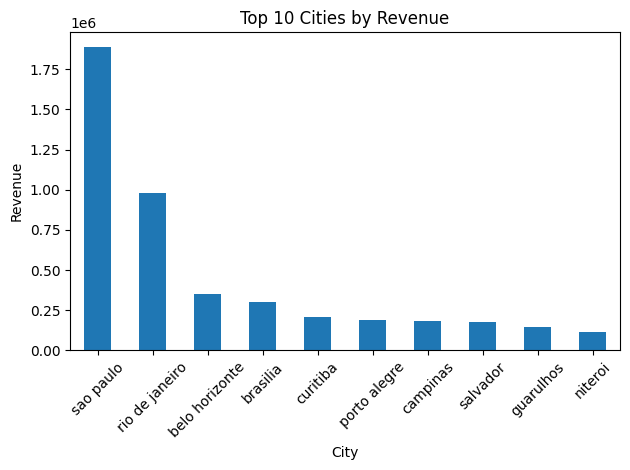

In [89]:
city_revenue = df.groupby('customer_city')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
city_revenue.plot(kind='bar')
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

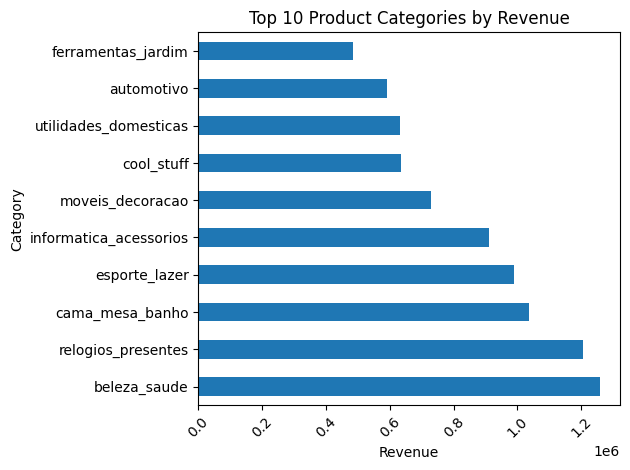

In [90]:
category_revenue = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
category_revenue.plot(kind='barh')
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

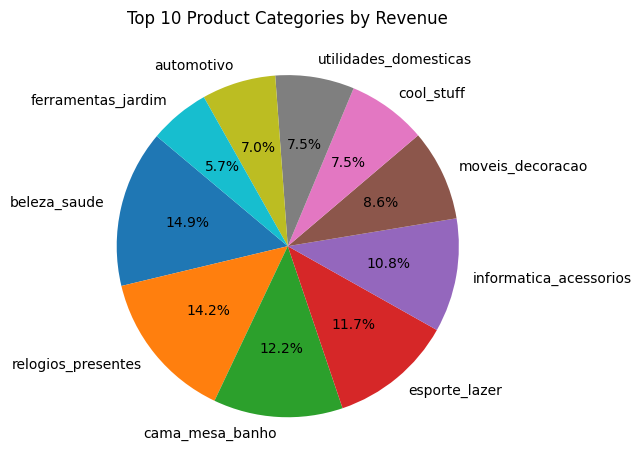

In [91]:
plt.figure()
category_revenue.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top 10 Product Categories by Revenue")
plt.ylabel("")
plt.tight_layout()
plt.show()